# Analysis of Training Circuits

In [2]:
%matplotlib inline

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4"  

import numpy as np
import jax.numpy as jnp
import pennylane as qml
import matplotlib.pyplot as plt
from qugen.main.data.data_handler import load_data, PITNormalizer, PITNormalizerNumPy
from qugen.main.data.helper import create_histogram_marginal_plot
from qugen.main.generator.discrete_qcbm_model_handler import DiscreteQCBMModelHandler

from typing import Tuple, List

def generate_samples_numpy(
    binary_samples: np.ndarray,
    n_registers: int,
    n_qubits: int,
    noisy: bool = True
) -> np.ndarray:
    """
    Convert binary quantum measurement samples to continuous samples.
    Pure NumPy implementation to avoid JAX GPU issues.
    
    Args:
        binary_samples: Binary measurement samples from quantum circuit
        n_registers: Number of registers (dimensions)
        n_qubits: Total number of qubits
        noisy: Whether to add noise to samples
        
    Returns:
        Continuous samples in [0, 1] range
    """
    width = 1 / (np.power(2**n_qubits, (1/n_registers)))
    
    if noisy:
        noise = 0.5 * width * np.random.uniform(
            low=-1, high=1,
            size=(len(binary_samples), n_registers)
        )
    else:
        noise = np.zeros((len(binary_samples), n_registers))
    
    noise = np.array(noise)
    n = 2**(n_qubits // n_registers)
    
    # Split the binary strings for each dimension into separate arrays
    samples_dims = []
    for dim in range(n_registers):
        start_idx = dim * n_qubits // n_registers
        end_idx = (dim + 1) * n_qubits // n_registers
        samples_dims.append(binary_samples[:, start_idx:end_idx])
    
    # Calculate the decimal representation of the binary strings
    def center_coords(coord, n):
        return np.array(coord) / n + 0.5 / n
    
    points_list = []
    for dim in samples_dims:
        # For each sample in this dimension
        indices = []
        for sample in dim:
            # Convert binary to decimal: dot product with powers of 2
            powers_of_2 = 2 ** np.arange(0, len(sample))
            decimal_value = np.dot(powers_of_2, sample[::-1])
            indices.append(decimal_value)
        points_list.append(center_coords(np.array(indices), n))
    
    points = np.vstack(points_list).T
    return points + noise

def kl_divergence_numpy(p: np.ndarray, q: np.ndarray, eps: float = 1e-6) -> float:
    """
    Compute KL divergence using NumPy (avoids JAX GPU issues).
    
    Args:
        p: True probability distribution
        q: Learned probability distribution
        eps: Small epsilon for numerical stability
        
    Returns:
        KL divergence value
    """
    return np.sum(p * np.log((p + eps) / (q + eps)))

def load_target_distribution(
    data_path: str, 
    n_qubits: int, 
    n_registers: int
) -> Tuple[np.ndarray, np.ndarray, List, List]:
    """
    Load target distribution and create histogram bins.
    
    Args:
        data_path: Path to synthetic 2D data file
        n_qubits: Total number of qubits
        n_registers: Number of registers (dimensions)
        
    Returns:
        Tuple of (data, true_probability, all_bins, all_ranges)
    """
    # Load synthetic data
    data = np.load(data_path)
    
    # Create histogram bins and ranges
    all_bins = []
    all_ranges = []
    n = 2 ** (n_qubits // n_registers)
    for _ in range(n_registers):
        all_bins.append(n)
        all_ranges.append([0, 1])
    
    # Compute true probability distribution
    data_histogram = np.histogramdd(data, bins=all_bins, range=all_ranges)
    true_probability = data_histogram[0] / np.sum(data_histogram[0])
    
    return data, true_probability, all_bins, all_ranges

# QASM to PennyLane - with fallback for missing pennylane-qiskit
def load_qasm_to_pennylane(qasm_file_path, n_qubits=8):
    """
    Load a QASM file to PennyLane. Tries native support first, falls back to custom parser.
    
    Args:
        qasm_file_path: Path to the QASM file
        n_qubits: Number of qubits in the circuit
        
    Returns:
        PennyLane QNode that implements the circuit
    """
    import re
    
    # Read the QASM file
    with open(qasm_file_path, 'r') as f:
        qasm_string = f.read()
    
    # Create device
    dev = qml.device('default.qubit', wires=n_qubits)
    
    dev_sample = qml.device('default.qubit', wires=n_qubits, shots=100000)
    # Try native PennyLane QASM support first
    try:
        @qml.qnode(dev)
        def circuit_native():
            qml.from_qasm(qasm_string)
            return qml.state()
        
        @qml.qnode(dev)
        def circuit_probs_native():
            qml.from_qasm(qasm_string)
            return qml.probs(wires=range(n_qubits))
        
        @qml.qnode(dev_sample)
        def circuit_sample_native():
            qml.from_qasm(qasm_string)
            return qml.sample(wires=range(n_qubits))
        
        # Test if it works
        _ = circuit_native()
        print(f"✅ Using native PennyLane QASM support for: {qasm_file_path}")
        return circuit_native, circuit_probs_native, circuit_sample_native
        
    except RuntimeError as e:
        if "pennylane-qiskit" in str(e):
            print(f"⚠️  Native QASM support unavailable (pennylane-qiskit not installed)")
            print(f"📝 Falling back to custom QASM parser...")
        else:
            raise e
 
    return None, None, None

def manual_pit_inverse_transform(samples_uniform, reverse_lookup, epsilon=1e-6):
    """Manual implementation of PIT inverse transform without JAX JIT."""

    # Apply epsilon correction
    data = samples_uniform * (1 + epsilon)

    n_samples = data.shape[0]
    n_dims = reverse_lookup.shape[0]
    n_lookup_samples = reverse_lookup.shape[1]

    result = np.zeros_like(data)

    for sample_idx in range(n_samples):
        for dim in range(n_dims):
            # Scale to lookup index
            value = data[sample_idx, dim] * (n_lookup_samples - 1)

            # Get floor and ceiling indices
            idx_low = int(np.floor(value))
            idx_high = int(np.ceil(value))

            # Clamp indices to valid range
            idx_low = max(0, min(idx_low, n_lookup_samples - 1))
            idx_high = max(0, min(idx_high, n_lookup_samples - 1))

            # Get values from lookup table
            val_low = reverse_lookup[dim, idx_low]
            val_high = reverse_lookup[dim, idx_high]

            # Linear interpolation
            if idx_low == idx_high:
                result[sample_idx, dim] = val_low
            else:
                weight = value - idx_low
                result[sample_idx, dim] = val_low * (1 - weight) + val_high * weight

    return result

## QASM Circuit Loading and Sampling

Bug in Pennylane that prevents loading circuits from QASM files.

In [19]:
N_QUBITS=8
N_REGISTERS=2

# Load the QASM file
qasm_file = "experiments/discrete_X_2D_copula_pit_qcbm_46b6/circuit_epoch_500_fixed.qasm"
qugen_circuit, qugen_circuit_probs, qugen_circuit_sample = load_qasm_to_pennylane(qasm_file)

# Execute the circuit
quantum_state = qugen_circuit()
print(f"\nQuantum state shape: {quantum_state.shape}")
print(f"State vector norm: {np.abs(quantum_state @ quantum_state.conj()):.6f}")

# Get probability distribution
probabilities = qugen_circuit_probs()
print(f"Probability distribution shape: {probabilities.shape}")
print(f"Probability sum: {np.sum(probabilities):.6f}")


# Get probability distribution()
quantum_samples = qugen_circuit_sample()
print(f"Quantum samples shape: {quantum_samples.shape}")


✅ Using native PennyLane QASM support for: experiments/discrete_X_2D_copula_pit_qcbm_46b6/circuit_epoch_500_fixed.qasm

Quantum state shape: (256,)
State vector norm: 1.000000
Probability distribution shape: (256,)
Probability sum: 1.000000
Quantum samples shape: (100000, 8)


In [20]:
continuous_samples = generate_samples_numpy(
    quantum_samples, 
    n_registers=N_REGISTERS, 
    n_qubits=N_QUBITS, 
    noisy=True
)

reverse_lookup = np.load("experiments/discrete_X_2D_copula_pit_qcbm_46b6/reverse_lookup.npy")
transformer = PITNormalizerNumPy(reverse_lookup, epsilon=1e-6)
continuous_samples_orig = transformer.inverse_transform(continuous_samples)

continuous_samples_hist, _ = np.histogramdd(continuous_samples_orig, bins=16, range=[[0,1],[0,1]])
continuous_samples_hist = continuous_samples_hist / np.sum(continuous_samples_hist)  

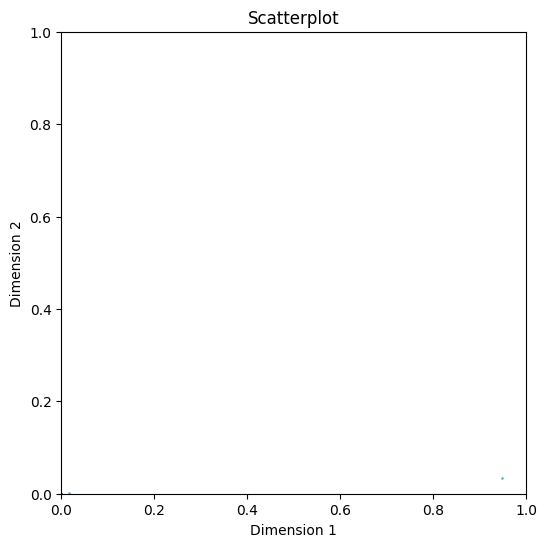

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt 
fig, ax1 = plt.subplots(figsize=(6, 6))

  # Scatterplot
ax1.scatter(
    continuous_samples_hist[:, 0],
    continuous_samples_hist[:, 1],
    alpha=0.5,
    s=1
)
ax1.set_title('Scatterplot')
ax1.set_xlabel('Dimension 1')
ax1.set_ylabel('Dimension 2')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
plt.show()

In [11]:
probabilities

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [42]:
weights = np.load("experiments/discrete_X_2D_copula_pit_qcbm_46b6/parameters_training_iteration=500.npy", allow_pickle=True)
print(f"Loaded weights shape: {weights.shape}")
print(f"Weights sample: {weights[:5]}")

Loaded weights shape: (2,)
Weights sample: [array([ 0.87174062,  3.13998737,  0.64583863,  2.71132644,  0.07390463,
         0.23337915,  3.1371837 ,  0.01696711,  1.36677003,  3.13944532,
         3.12183897,  1.46410787,  1.66542343, -0.02233155,  0.49871452,
         1.40096496, -0.02017636,  3.06226077,  1.13607633, -0.07941758,
         1.98799399,  0.15125827,  0.24568049,  2.81704869,  1.47335649,
         3.12457019,  1.73752084, -0.10880792,  2.00026748,  0.36673942,
         1.33973312,  3.12499837,  1.52335852,  3.13601497,  1.15175337,
         3.13182295,  3.1078216 ,  3.12381896, -0.03621137,  3.13003725,
         3.14142907,  3.14159208,  1.08043689,  3.14139534,  1.11732939,
         1.94488366,  3.13409032,  1.82523912,  3.13712992,  3.13795329,
         3.140379  , -0.0996728 ,  3.1407632 ,  3.06126513,  3.14159265,
         3.13762   ,  3.14118651,  3.06334893,  3.01714118,  3.14134364,
         1.5645449 ,  1.43032153,  1.72122559,  1.4486309 ,  1.85210292,
        

Computing Samples from the circuit's probability distribution


## Loading via QuGen Classes

In [5]:
data_set_name = "X_2D"
data_set_path = f"./training_data/{data_set_name}"
data, _ = load_data(data_set_path)

model = DiscreteQCBMModelHandler()
model.load_best('discrete_X_2D_standard_none_qcbm_2199')
samples = model.predict(10000)

Auto-selected best epoch 700 with KL divergence: 0.679417
Successfully loaded model 'discrete_X_2D_standard_none_qcbm_2199' from epoch 700
Model configuration: 8 qubits, 2 registers, circuit_type='standard', transformation='none'


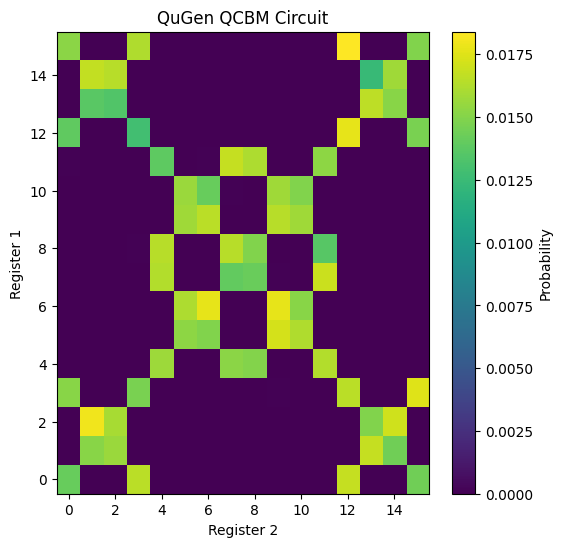

In [6]:
%matplotlib inline
# 2D binned histogram: dim 0 on X axis, dim 1 on Y axis
learned_histogram_np, _ = np.histogramdd(samples, bins=16, range=[[0,1],[0,1]])
learned_histogram_np = learned_histogram_np / np.sum(learned_histogram_np)  

# Create a single plot
fig, ax = plt.subplots(figsize=(6, 6))

# QuGen circuit output
im = ax.imshow(learned_histogram_np, cmap='viridis', aspect='auto', origin='lower')
ax.set_title('QuGen QCBM Circuit')
ax.set_xlabel('Register 2')
ax.set_ylabel('Register 1')
plt.colorbar(im, ax=ax, label='Probability')
plt.show()

## Analyse Data

In [ ]:
def your_quantum_probs():
    # Your actual quantum circuit probability generation
    return qugen_circuit_probs()

from debug_distribution_mismatch import debug_distributions
results = debug_distributions(
    "discrete_X_2D_copula_pit_qcbm_bafc",
    "training_data/X_2D",
    quantum_probs_func=your_quantum_probs
)


7. SUMMARY AND RECOMMENDATIONS
Training KL divergence (transformed space): 0.224067
Current KL divergence (uniform space): 18.792740
Current KL divergence (original space): 18.272095

⚠️  ISSUE DETECTED: Large KL divergence mismatch
Possible causes:
- Wrong weights being used in quantum circuit
- Quantum circuit implementation doesn't match training
- Bug in probability generation

Diagnostic plot saved as: debug_discrete_X_2D_copula_pit_qcbm_bafc_distributions.png


In [ ]:
# Re-import matplotlib.pyplot to fix the plt variable
import matplotlib.pyplot as plt

#### Load target data first to define missing variables
data_set_path = "training_data/X_2D.npy"

target_data, true_probability, all_bins, all_ranges = load_target_distribution(
    data_path=data_set_path,
    n_qubits=N_QUBITS,
    n_registers=N_REGISTERS
)

normalizer = PITNormalizer()
transformed_data = normalizer.fit_transform(target_data)

# Compute discrete probabilities from transformed data
transformed_true_probabilities, bin_edges = np.histogramdd(
    transformed_data,   
    bins=all_bins, 
    range=all_ranges
)

# Normalize to probabilities
transformed_true_probabilities = transformed_true_probabilities / np.sum(transformed_true_probabilities)

print(f"Target data shape: {target_data.shape}")
print(f"Transformed data range: [{transformed_data.min():.3f}, {transformed_data.max():.3f}]")
print(f"Discrete probabilities shape: {transformed_true_probabilities.shape}")
print(f"Number of bins per dimension: {all_bins}")
print(f"Total bins: {transformed_true_probabilities.size}")
print(f"Non-zero probability bins: {np.count_nonzero(transformed_true_probabilities)}")
print(f"Probability sum: {transformed_true_probabilities.sum():.6f}")

# Reshape to 2D for visualization
n = 2 ** (N_QUBITS // N_REGISTERS)
prob_2d = probabilities.reshape(n, n).T

# Make sure samples_original_probs is defined (check if it exists from previous cell)
if 'samples_original_probs' not in locals():
    print("⚠️ samples_original_probs not defined. Please run the previous cell first.")
    # Create a dummy one for now to prevent errors
    samples_original_probs = prob_2d.copy()

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# QuGen circuit output
ax = axes[0]
im1 = ax.imshow(samples_original_probs, cmap='viridis', aspect='auto')
ax.set_title(f'QuGen QCBM Circuit\n({parser_type} parser)')
ax.set_xlabel('Register 2')
ax.set_ylabel('Register 1')
plt.colorbar(im1, ax=ax)

# Target distribution
ax = axes[1]
im2 = ax.imshow(transformed_true_probabilities, cmap='viridis', aspect='auto')
ax.set_title('Target Distribution')
ax.set_xlabel('Register 2')
ax.set_ylabel('Register 1')
plt.colorbar(im2, ax=ax)

# Difference
ax = axes[2]
diff = np.abs(prob_2d - transformed_true_probabilities)
im3 = ax.imshow(diff, cmap='Reds', aspect='auto')
ax.set_title(f'Absolute Difference\nMax = {np.max(diff):.6f}')
ax.set_xlabel('Register 2')
ax.set_ylabel('Register 1')
plt.colorbar(im3, ax=ax)

plt.tight_layout()
plt.show()

# Compute KL divergence
kl_div = kl_divergence_numpy(true_probability, prob_2d)
print(f"\nKL divergence from target: {kl_div:.6f}")

# Draw the circuit
print(f"\nCircuit diagram ({parser_type}):")
print(qml.draw(qugen_circuit)())

# Additional analysis
print(f"\n📈 CIRCUIT ANALYSIS:")
print(f"  Parser used: {parser_type}")
print(f"  KL divergence: {kl_div:.6f}")
print(f"  Max probability difference: {np.max(diff):.6f}")
print(f"  Mean probability difference: {np.mean(diff):.6f}")

# Compare with best circuits from our dataset if available
if 'loaded_train_energy' in locals():
    min_kl_in_dataset = np.min(loaded_train_energy)
    print(f"  Best KL in our dataset: {min_kl_in_dataset:.6f}")
    print(f"  QuGen vs best: {'✅ Better' if kl_div < min_kl_in_dataset else '❌ Worse'}")
    print(f"  Improvement factor: {min_kl_in_dataset / kl_div:.2f}x")

Target data shape: (50000, 2)
Transformed data range: [0.000, 1.000]
Discrete probabilities shape: (16, 16)
Number of bins per dimension: [16, 16]
Total bins: 256
Non-zero probability bins: 60
Probability sum: 1.000000

KL divergence from target: 9.931761

Circuit diagram (native):


📈 CIRCUIT ANALYSIS:
  Parser used: native
  KL divergence: 9.931761
  Max probability difference: 0.969120
  Mean probability difference: 0.007571


In [ ]:
# Load the saved reverse lookup
reverse_lookup_path = "experiments/discrete_X_2D_copula_pit_qcbm_c40e/reverse_lookup.npy"
reverse_lookup = np.load(reverse_lookup_path)

print(f"Reverse lookup shape: {reverse_lookup.shape}")

# Get probabilities from quantum circuit
probabilities = qugen_circuit_probs()

# Convert probabilities back to samples in [0,1] space
# First, generate samples from the probability distribution
n_samples = 1000  # Adjust as needed
n_bins_per_dim = 2**(N_QUBITS // N_REGISTERS)  # 16 for 8 qubits, 2 registers

# Flatten probabilities and create sample indices
flat_probs = probabilities.flatten()
flat_probs = flat_probs / np.sum(flat_probs)  # Ensure normalized

# Sample from the discrete distribution
sample_indices = np.random.choice(
    len(flat_probs),
    size=n_samples,
    p=flat_probs
)

# Convert flat indices back to 2D indices
samples_discrete = np.unravel_index(sample_indices, probabilities.shape)
samples_discrete = np.array(samples_discrete).T

# Convert discrete indices to [0,1] continuous values
samples_uniform = samples_discrete / n_bins_per_dim + np.random.uniform(0, 1/n_bins_per_dim, samples_discrete.shape)

# Now use the reverse PIT transform to get back to original space
def reverse_pit_transform(uniform_samples, reverse_lookup):
    """Apply reverse PIT transformation using saved lookup table."""
    n_dims = reverse_lookup.shape[0]
    n_lookup_samples = reverse_lookup.shape[1]

    # Scale uniform samples to lookup indices
    scaled_samples = uniform_samples * (n_lookup_samples - 1)

    # Apply interpolation for each dimension
    original_samples = []
    for dim in range(n_dims):
        dim_samples = scaled_samples[:, dim]

        # Get floor and ceiling indices
        indices_low = np.floor(dim_samples).astype(int)
        indices_high = np.ceil(dim_samples).astype(int)

        # Ensure indices are within bounds
        indices_low = np.clip(indices_low, 0, n_lookup_samples - 1)
        indices_high = np.clip(indices_high, 0, n_lookup_samples - 1)

        # Get values from lookup table
        values_low = reverse_lookup[dim, indices_low]
        values_high = reverse_lookup[dim, indices_high]

        # Linear interpolation
        weights = dim_samples - indices_low
        interpolated = values_low * (1 - weights) + values_high * weights

        original_samples.append(interpolated)

    return np.array(original_samples).T

# Apply reverse PIT transformation
samples_original = reverse_pit_transform(samples_uniform, reverse_lookup)

print(f"Generated {len(samples_original)} samples in original space")
print(f"Sample range: X1=[{samples_original[:, 0].min():.3f}, {samples_original[:, 0].max():.3f}], X2=[{samples_original[:, 1].min():.3f}, {samples_original[:, 1].max():.3f}]")

# Visualize results
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Samples in [0,1] space
ax1.scatter(samples_uniform[:, 0], samples_uniform[:, 1], alpha=0.6)
ax1.set_title('Generated Samples (Uniform [0,1] Space)')
ax1.set_xlabel('X1 (uniform)')
ax1.set_ylabel('X2 (uniform)')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Samples in original space
ax2.scatter(samples_original[:, 0], samples_original[:, 1], alpha=0.6)
ax2.set_title('Generated Samples (Original Space)')
ax2.set_xlabel('X1 (original)')
ax2.set_ylabel('X2 (original)')

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'experiments/discrete_X_2D_copula_pit_qcbm_c40e/reverse_lookup.npy'